# Episode 1 — What is a feature, really?

**Goal:** show two things numerically:

1. A feature is a **coordinate axis**, not just a column. Rotate the basis → the model's coefficients change but the accuracy doesn't. The information didn't change — only the description of it did.
2. A **one-hot encoded categorical column** produces **orthogonal unit vectors**, so every category is equidistant from every other. That's why embeddings exist.

This notebook is a live demo for the episode script.

## Setup — use the `.venv` at the tutorial root

This notebook is designed to run against the virtual environment at `dimensionality_reduction/.venv`. Two ways to wire it up:

### Option A — VS Code (recommended)

1. Open this notebook in VS Code.
2. Click the **kernel picker** in the top-right of the notebook (says "Select Kernel" or shows the current kernel name).
3. Choose **Python Environments...** → pick `.venv (Python 3.x)` — VS Code auto-detects it from the tutorial root.

That's it. VS Code will remember the choice for this notebook.

### Option B — Register the venv as a named Jupyter kernel

Useful if you launch `jupyter lab` / `jupyter notebook` outside VS Code.

```bash
# from dimensionality_reduction/
source .venv/bin/activate
python -m ipykernel install --user \
  --name dimensionality-reduction \
  --display-name "Python (dimensionality_reduction .venv)"
```

Then in the kernel picker choose **Python (dimensionality_reduction .venv)**.

### First-time setup (if the `.venv` doesn't exist yet)

```bash
# from dimensionality_reduction/
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

### Sanity check

Run the cell below. If the reported interpreter path contains `dimensionality_reduction/.venv`, you're on the right kernel.


In [2]:
import sys
import importlib.metadata as md

print(f'python executable: {sys.executable}')
print(f'python version:    {sys.version.split()[0]}')
print()
for pkg in ('numpy', 'pandas', 'scikit-learn', 'matplotlib'):
    try:
        print(f'  {pkg:14s} {md.version(pkg)}')
    except md.PackageNotFoundError:
        print(f'  {pkg:14s} NOT INSTALLED  <- run: pip install -r requirements.txt')

print()
if '.venv' in sys.executable:
    print('OK: this notebook is running inside the tutorial .venv.')
else:
    print('WARNING: not running inside .venv. See the setup cell above.')


python executable: /Library/Developer/CommandLineTools/usr/bin/python3
python version:    3.9.6

  numpy          2.0.2
  pandas         2.3.3
  scikit-learn   NOT INSTALLED  <- run: pip install -r requirements.txt
  matplotlib     NOT INSTALLED  <- run: pip install -r requirements.txt



In [9]:
%pip install matplotlib numpy pandas scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

RNG = 0
np.set_printoptions(precision=4, suppress=True)

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 7.4 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 439 kB/s eta 0:00:01
     |████████████████████████████████| 64 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 7.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 8.3 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 7.8 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 7.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Part 1 — Features are coordinate axes

Two Gaussian blobs in 2D — a trivial classification problem. The columns `feature_1` and `feature_2` are just the x- and y-axes of the plot.

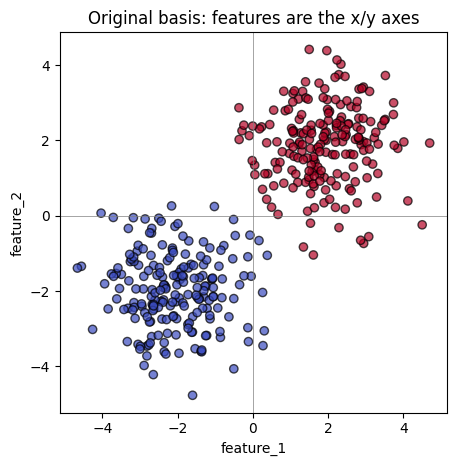

In [10]:
X, y = make_blobs(
    n_samples=400,
    centers=[[-2.0, -2.0], [2.0, 2.0]],
    cluster_std=1.0,
    random_state=RNG,
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('feature_1')
ax.set_ylabel('feature_2')
ax.set_title('Original basis: features are the x/y axes')
ax.set_aspect('equal')
plt.show()

In [11]:
clf = LogisticRegression().fit(X, y)
print('=== Original basis ===')
print(f'coefficients: {clf.coef_[0]}')
print(f'intercept:    {clf.intercept_[0]:.4f}')
print(f'accuracy:     {clf.score(X, y):.4f}')

=== Original basis ===
coefficients: [2.1422 2.0005]
intercept:    0.1150
accuracy:     1.0000


## Part 2 — Rotate the basis (same data, new axes)

A rotation is an **isometry** — it doesn't move points relative to each other, only relative to the axes. If features were just "columns of data" this would be irrelevant. Because features are *axes*, rotation gives the same points *new coordinates*.

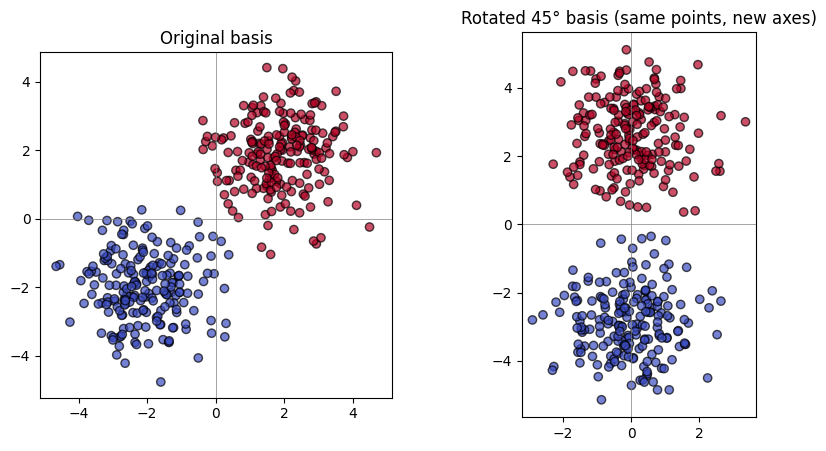

In [18]:
theta = np.pi / 4  # 45 degrees
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])
X_rot = X @ R.T

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, data, title in zip(
    axes,
    [X, X_rot],
    ['Original basis', 'Rotated 45° basis (same points, new axes)'],
):
    ax.scatter(data[:, 0], data[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(title)
    ax.set_aspect('equal')
plt.show()

In [20]:
clf_rot = LogisticRegression().fit(X_rot, y)

print('=== Original basis ===')
print(f'coefficients: {clf.coef_[0]}')
print(f'accuracy:     {clf.score(X, y):.4f}')
print()
print('=== Rotated basis ===')
print(f'coefficients: {clf_rot.coef_[0]}')
print(f'accuracy:     {clf_rot.score(X_rot, y):.4f}')
print()
print('Notice: accuracy is identical, coefficients are not.')
print('The model changed because the basis changed, not because the information did.')

=== Original basis ===
coefficients: [2.1422 2.0005]
accuracy:     1.0000

=== Rotated basis ===
coefficients: [0.1002 2.9293]
accuracy:     1.0000

Notice: accuracy is identical, coefficients are not.
The model changed because the basis changed, not because the information did.


**Takeaway.** The geometric truth (two well-separated clusters) is invariant. The *numbers* used to describe each point depend on the basis. Every dim-reduction technique in this series is a way to pick a **better** basis — one with fewer axes, or clearer separation, or less redundancy.

## Interlude — Vectors, unit vectors, orthogonality

Three definitions Part 3 leans on. If you already know these, skim.

- **Vector.** A list of numbers, e.g. `[3, 4]`. Geometrically, a point's position from the origin, described in some basis. **Every row of your dataset is a vector.** That is the mental switch.
- **Length (norm).** For `v = [a, b]`, the Euclidean length is $\|v\| = \sqrt{a^2 + b^2}$. Extends to any dimension: $\|v\| = \sqrt{\sum_i v_i^2}$. In numpy: `np.linalg.norm(v)`.
- **Unit vector.** A vector of length 1 — *pure direction, no magnitude*. Any nonzero vector can be normalized: $\hat{v} = v / \|v\|$. Unit vectors are why cosine similarity, attention scores, and gradient normalization work — they separate "which direction" from "how much."
- **Orthogonal.** Two vectors are perpendicular iff their **dot product is zero**: $v \cdot w = \sum_i v_i w_i = 0$. In high dimensions our visual intuition of "right angles" collapses; the algebra doesn't — orthogonality is *defined* by this equation, not by pictures.
- **Orthogonal unit vector.** A unit vector that is orthogonal to some other unit vector(s). The **standard basis** in $n$-D is $n$ such vectors: $e_1 = [1,0,\dots,0]$, $e_2 = [0,1,\dots,0]$, $\dots$ — each has length 1 and every pair is orthogonal.

**Bridge to Part 3.** One-hot encoding a categorical column places every category on one of the standard basis vectors. That's why we call them "orthogonal unit vectors" — it's literally what they are.


In [14]:
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

print('Lengths (norms):')
print(f'  ||e1|| = {np.linalg.norm(e1):.4f}   -> unit vector (length 1)')
print(f'  ||e2|| = {np.linalg.norm(e2):.4f}   -> unit vector (length 1)')
print()

print('Dot product:')
print(f'  e1 . e2 = {np.dot(e1, e2):.4f}   -> zero means orthogonal')
print()

# Normalize an arbitrary vector: strip magnitude, keep direction.
v = np.array([3.0, 4.0])
v_hat = v / np.linalg.norm(v)
print(f'Arbitrary v         = {v}, ||v|| = {np.linalg.norm(v):.4f}')
print(f'Normalized v (unit) = {v_hat}, ||v_hat|| = {np.linalg.norm(v_hat):.4f}')
print()

# The bridge: a one-hot row IS a standard basis vector.
toyota  = np.array([1, 0, 0])
honda   = np.array([0, 1, 0])
ferrari = np.array([0, 0, 1])

print('One-hot rows are standard basis vectors:')
print(f'  ||toyota||  = {np.linalg.norm(toyota):.2f},  toyota . honda   = {int(np.dot(toyota, honda))}')
print(f'  ||honda||   = {np.linalg.norm(honda):.2f},  toyota . ferrari = {int(np.dot(toyota, ferrari))}')
print(f'  ||ferrari|| = {np.linalg.norm(ferrari):.2f},  honda . ferrari  = {int(np.dot(honda, ferrari))}')
print()
print('All unit length, all pairwise dot products zero.')
print('That is what "orthogonal unit vector" means, numerically.')


Lengths (norms):
  ||e1|| = 1.0000   -> unit vector (length 1)
  ||e2|| = 1.0000   -> unit vector (length 1)

Dot product:
  e1 . e2 = 0.0000   -> zero means orthogonal

Arbitrary v         = [3. 4.], ||v|| = 5.0000
Normalized v (unit) = [0.6 0.8], ||v_hat|| = 1.0000

One-hot rows are standard basis vectors:
  ||toyota||  = 1.00,  toyota . honda   = 0
  ||honda||   = 1.00,  toyota . ferrari = 0
  ||ferrari|| = 1.00,  honda . ferrari  = 0

All unit length, all pairwise dot products zero.
That is what "orthogonal unit vector" means, numerically.


## Interlude — What is a *basis*?

A **basis** is a set of vectors that describe every point in a space with **no gaps and no redundancy**:

- **Spans:** you can reach every point in the space by combining basis vectors.
- **Linearly independent:** no basis vector can be built from the others (nothing wasted).

The number of vectors in any basis is the **dimension** of the space.

### Three ways to see it

- **As axes.** In 2D, the standard basis is $e_1 = [1, 0]$ and $e_2 = [0, 1]$ — the x and y axes. But $b_1 = [\tfrac{\sqrt{2}}{2}, \tfrac{\sqrt{2}}{2}]$ and $b_2 = [-\tfrac{\sqrt{2}}{2}, \tfrac{\sqrt{2}}{2}]$ (a 45° rotated pair) is *also* a valid basis for the same 2D space.
- **As a description language.** A point in space is a fixed location. Coordinates like $(3, 4)$ are just its *description* in some basis. Change the basis and the numbers change; the point doesn't move.
- **As "how many independent directions do I need?"** The dimension of a space is the size of any basis for it.

### Change of basis, in one formula

If $B$ is the matrix whose *columns* are the new basis vectors (expressed in the old basis), then a point $x$ has **new coordinates** $x' = B^{-1} x$. For an **orthonormal** basis (unit-length, mutually perpendicular), this simplifies to $x' = B^\top x$ — no inverse needed. That's the trick every rotation, PCA projection, and attention head is using.

### Why this is the whole series' spine

Every technique we'll cover is answering: **"What's a better basis for this data?"**

| Technique | What its basis is |
|---|---|
| Raw features | Whatever axes the dataset came with (dollars, kg, category flags…) |
| **One-hot encoding** | Standard basis in a giant space — one axis per category |
| **PCA** | Axes aligned with directions of maximum variance |
| **LDA** | Axes that maximize class separation |
| **Autoencoder / embedding** | Axes learned end-to-end to make a task easier |
| **LoRA** | A low-dim basis for *fine-tune updates*, not the model itself |
| **Product Quantization** | 8 tiny bases (one per sub-vector), each with 256 codewords |

When you hear "PCA finds a new basis," "the embedding lives in a 768-dim space," or "LoRA restricts updates to a rank-16 subspace" — they're all saying the same thing: *here's a better set of axes for the job*.

The cell below shows this numerically: the same physical point (3, 4), described in two different bases.


In [ ]:
# The same point described in two different bases.
x = np.array([3.0, 4.0])  # physical location

B1 = np.eye(2)  # basis 1: standard basis

# Basis 2: 45-degree rotated orthonormal basis.
s = np.sqrt(2) / 2
B2 = np.array([
    [ s, -s],
    [ s,  s],
])

# For an orthonormal basis, new coords = B.T @ x.
coords_std = B1.T @ x
coords_rot = B2.T @ x

print(f'Point (physical location):     {x}')
print()
print(f'Coordinates in standard basis: {coords_std}')
print(f'  = {coords_std[0]:.4f} * e1 + {coords_std[1]:.4f} * e2')
print()
print(f'Coordinates in rotated basis:  {coords_rot}')
print(f'  = {coords_rot[0]:.4f} * b1 + {coords_rot[1]:.4f} * b2')
print()

# Reconstruct the point from each set of coordinates to prove they describe the same thing.
recon_std = B1 @ coords_std
recon_rot = B2 @ coords_rot
print(f'Reconstruct from standard coords: {recon_std}  -> back to (3, 4)')
print(f'Reconstruct from rotated coords:  {recon_rot}  -> back to (3, 4)')
print()
print('Same point. Two descriptions. Neither is more "correct" -')
print('they answer different questions.')


## Part 3 — One-hot encoding = orthogonal unit vectors

Now the setup for the entire rest of the series. Take a simple categorical column and one-hot encode it.

In [15]:
df = pd.DataFrame({'car': ['toyota', 'honda', 'ferrari', 'toyota', 'honda', 'ferrari']})
onehot = pd.get_dummies(df['car'], dtype=int)
onehot

,ferrari,honda,toyota
0,0,0,1
1,0,1,0
2,1,0,0
3,0,0,1
4,0,1,0
5,1,0,0


In [16]:
# Gram matrix: pairwise dot products between category columns.
# Off-diagonal zeros == columns are orthogonal.
gram = onehot.values.T @ onehot.values
pd.DataFrame(gram, index=onehot.columns, columns=onehot.columns)

,ferrari,honda,toyota
ferrari,2,0,0
honda,0,2,0
toyota,0,0,2


In [17]:
# Distance between each pair of category vectors. They are all sqrt(2).
labels = ['toyota', 'honda', 'ferrari']
vectors = np.eye(3)

for i, j in combinations(range(3), 2):
    dist = np.linalg.norm(vectors[i] - vectors[j])
    print(f'||{labels[i]:>7} - {labels[j]:>7}|| = {dist:.4f}')

print()
print('Every category is equidistant from every other.')
print('The model literally cannot know that Toyota is closer to Honda than to Ferrari.')
print('That gap is exactly what learned embeddings (Episode 18) fix.')

|| toyota -   honda|| = 1.4142
|| toyota - ferrari|| = 1.4142
||  honda - ferrari|| = 1.4142

Every category is equidistant from every other.
The model literally cannot know that Toyota is closer to Honda than to Ferrari.
That gap is exactly what learned embeddings (Episode 18) fix.


## Recap

- **Features are coordinate axes**, not columns. Data lives in a vector space; columns just label the axes.
- **Changing the basis changes the model's numbers, not its accuracy** (for information-preserving transforms). Everything in this series is a way to change the basis on purpose.
- **One-hot encoding places every category on an orthogonal unit vector**, so pairwise distances are identical. That destroys similarity information and motivates every technique from PCA onward.

### The pipeline (memorize this)

```
raw column → one-hot → dim reduction → reduced features → model
```

### Three misconceptions we'll correct across the series

1. PCA is **not regression** — unsupervised, minimizes perpendicular distance, uses SVD. (Ep. 12)
2. You do **not** re-encode after dim reduction. The reduced features *are* the model input. (Ep. 4)
3. Do **not** run plain PCA on raw one-hot columns — use truncated SVD, embeddings, or target encoding with out-of-fold. (Ep. 4, Ep. 13)

### Next episode

**Ep. 2 — Variable types & the scale trap.** Why standardization matters (it's about the loss surface, not "fairness"), and the two cases where standardization is the wrong move.